IMPORTING LIBRARIES AND SETTING ENVIRONMENTS

In [1]:
import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import GroupKFold, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
import lightgbm as lgb
import shap
from catboost import CatBoostRegressor

RANDOM_SEED = 42    #using as standard 
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('scikit-learn', __import__('sklearn').__version__)
print('lightgbm', lgb.__version__)
print('optuna', optuna.__version__)
print('shap', shap.__version__)
print('seaborn', sns.__version__)

c:\Users\abhis\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas 2.3.3
numpy 2.2.6
scikit-learn 1.7.2
lightgbm 4.7.0
optuna 4.9.0
shap 0.49.1
seaborn 0.13.2


LOADING DATA

In [3]:
# Attempt 1: Relative paths (Failed: FileNotFoundError when running from subfolder)
# train = pd.read_csv('../data/train-test.csv')
# validation = pd.read_csv('../data/validation.csv')

# Attempt 2: Hardcoded direct string paths (Worked, but fragile across operating systems)
# BASE_DIR = "d:/offcampus/projects/N_freight_rate_prediction"
# train = pd.read_csv(BASE_DIR + "/data/train-test.csv")

# Final Approach: Using Pathlib for cross-platform compatibility and clean path resolution
BASE_DIR = Path('d:/offcampus/projects/BN_freight_rate_prediction')
TRAIN_PATH = BASE_DIR / 'data' / 'train-test.csv'
VALIDATION_PATH = BASE_DIR / 'data' / 'validation.csv'
VALIDATION_TEMPLATE_PATH = BASE_DIR / 'data' / 'validation-predictions-template.csv'
DECEMBER_PATH = BASE_DIR / 'data' / 'december-chart-inputs.csv'

train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)
validation_template = pd.read_csv(VALIDATION_TEMPLATE_PATH)
december_inputs = pd.read_csv(DECEMBER_PATH)

print('train shape:', train.shape)
print('validation shape:', validation.shape)
print('validation_template shape:', validation_template.shape)
print('december_inputs shape:', december_inputs.shape)

# Quick check on column alignment
print("Missing columns in December inputs relative to Train:", set(train.columns) - set(december_inputs.columns))
train.head()

train shape: (48000, 14)
validation shape: (12000, 13)
validation_template shape: (12000, 2)
december_inputs shape: (31, 7)
Missing columns in December inputs relative to Train: {'pickup_lon', 'market_index', 'quote_signal', 'posted_rate', 'pickup_lat', 'delivery_lon', 'load_id', 'delivery_lat'}


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


DATA CLEANING AND COORDINATE MAPPING

In [4]:
# Attempt 1: Simple mean imputation across missing values
# train = train.fillna(train.mean())
# december_inputs = december_inputs.fillna(december_inputs.mean())
# Failed: Threw TypeError on string columns like 'pickup' and created unrealistic lat/lon values for December.

# Attempt 2: Dropping rows with missing values
# train = train.dropna()
# Failed: Lost ~15% of historical training data, including critical lane records.

# Final Approach: Route-level lookup mapping + median fallback for missing coordinates and market indicators
route_info = train[['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'market_index', 'quote_signal']].drop_duplicates(subset=['pickup', 'delivery'], keep='first')
december_inputs = december_inputs.merge(route_info, on=['pickup', 'delivery'], how='left')

fill_defaults = {
    'pickup_lat': train['pickup_lat'].median(),
    'pickup_lon': train['pickup_lon'].median(),
    'delivery_lat': train['delivery_lat'].median(),
    'delivery_lon': train['delivery_lon'].median(),
    'market_index': train['market_index'].median(),
    'quote_signal': train['quote_signal'].median(),
}

def fill_default(df, col, default):
    if col not in df.columns:
        df[col] = default
    else:
        df[col] = df[col].fillna(default)

for df in [train, validation, december_inputs]:
    # Fix negative weight anomaly found during initial data inspection
    df['weight'] = df['weight'].fillna(df['weight'].median()).abs()
    for col, default in fill_defaults.items():
        fill_default(df, col, default)
    df['equipment'] = df['equipment'].fillna('missing').astype(str)
    df['pickup'] = df['pickup'].astype(str)
    df['delivery'] = df['delivery'].astype(str)
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')

train = train.drop_duplicates().reset_index(drop=True)
print('Data cleaning complete. Remaining train NaNs:', train[['weight', 'market_index', 'pickup_lat']].isna().sum().to_dict())

Data cleaning complete. Remaining train NaNs: {'weight': 0, 'market_index': 0, 'pickup_lat': 0}


FEATURE ENGINEERING AND ROLLING STATISTICS

In [8]:
# Attempt 1: Straight-line distance using Euclidean coordinates
# train['distance_approx'] = np.sqrt((train['pickup_lat'] - train['delivery_lat'])**2 + (train['pickup_lon'] - train['delivery_lon'])**2)
# Abandoned: Insufficient precision for route distance modeling; failed to handle geographical curvature.

# Attempt 2: Independent rolling stats on train dataset only
# train['route_rolling_14d_mean'] = train.groupby('route')['posted_rate'].transform(lambda x: x.rolling(14).mean())
# Failed: Caused data leakage during CV evaluation and produced 100% NaN rolling values for validation/december sets.

# Final Approach: Haversine distance formula + Unified temporal stack for leak-free rolling features
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    return 3956 * (2 * np.arcsin(np.sqrt(a)))

def build_features(df):
    df = df.copy()
    for col in ['pickup', 'delivery', 'equipment']:
        df[col] = df[col].astype(str) if col in df.columns else ''

    for col in ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight']:
        df[col] = df[col].fillna(0.0) if col in df.columns else 0.0

    df['route'] = df['pickup'] + '|' + df['delivery']
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce')
    df['date_dayofweek'] = df['date'].dt.dayofweek.astype('int8')
    df['date_month'] = df['date'].dt.month.astype('int8')
    df['date_day'] = df['date'].dt.day.astype('int8')
    df['date_week'] = df['date'].dt.isocalendar().week.astype('int16')
    df['date_is_weekend'] = df['date_dayofweek'].isin([5, 6]).astype('int8')
    df['abs_lat_diff'] = (df['pickup_lat'] - df['delivery_lat']).abs()
    df['abs_lon_diff'] = (df['pickup_lon'] - df['delivery_lon']).abs()
    df['weight_per_mile'] = df['weight'] / df['distance'].replace(0, 1)
    df['pickup_to_delivery_dist'] = haversine_np(df['pickup_lon'], df['pickup_lat'], df['delivery_lon'], df['delivery_lat'])

    df['pickup_zone'] = df['pickup_lat'].round(1).astype(str) + '_' + df['pickup_lon'].round(1).astype(str)
    df['delivery_zone'] = df['delivery_lat'].round(1).astype(str) + '_' + df['delivery_lon'].round(1).astype(str)

    hubs = {'Chicago': (41.8781, -87.6298), 'Dallas': (32.7767, -96.7970), 'Atlanta': (33.7490, -84.3880), 'LA': (34.0522, -118.2437)}
    for hub_name, (hub_lat, hub_lon) in hubs.items():
        df[f'dist_pickup_to_{hub_name}'] = haversine_np(df['pickup_lon'], df['pickup_lat'], hub_lon, hub_lat)
        df[f'dist_delivery_to_{hub_name}'] = haversine_np(df['delivery_lon'], df['delivery_lat'], hub_lon, hub_lat)

    return df

train = build_features(train)
validation = build_features(validation)
december_inputs = build_features(december_inputs)

# Stack chronologically to compute index-safe rolling statistics across past timelines
train['dataset_marker'] = 'train'
validation['dataset_marker'] = 'val'
december_inputs['dataset_marker'] = 'dec'
validation['posted_rate'] = np.nan
december_inputs['posted_rate'] = np.nan

all_data = pd.concat([train, validation, december_inputs], ignore_index=True)
all_data = all_data.sort_values(['route', 'date']).reset_index(drop=True)

all_data['market_index'] = all_data.groupby('route')['market_index'].ffill()
all_data['quote_signal'] = all_data.groupby('route')['quote_signal'].ffill()

def add_rolling_stats(df, group_cols, window=14):
    df = df.copy()
    df['_orig_idx'] = df.index
    df = df.sort_values(group_cols + ['date'])
    
    prefix = '_'.join(group_cols)
    mean_col = f"{prefix}_rolling_{window}d_mean"
    count_col = f"{prefix}_rolling_{window}d_count"
    
    df[mean_col] = df.groupby(group_cols)['posted_rate'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    df[count_col] = df.groupby(group_cols)['posted_rate'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).count())
    
    df = df.sort_values('_orig_idx').drop(columns=['_orig_idx'])
    global_mean = df[df['dataset_marker'] == 'train']['posted_rate'].mean()
    df[mean_col] = df[mean_col].fillna(global_mean)
    df[count_col] = df[count_col].fillna(0)
    return df

for col_group in [['route'], ['pickup'], ['delivery'], ['equipment']]:
    all_data = add_rolling_stats(all_data, col_group, window=14)

# FIX: Added .reset_index(drop=True) to ensure clean 0-indexed integer labels
train = all_data[all_data['dataset_marker'] == 'train'].drop(columns=['dataset_marker']).reset_index(drop=True)
validation = all_data[all_data['dataset_marker'] == 'val'].drop(columns=['dataset_marker']).reset_index(drop=True)
december_inputs = all_data[all_data['dataset_marker'] == 'dec'].drop(columns=['dataset_marker']).reset_index(drop=True)

print("Feature engineering complete. Total train features:", train.shape[1])

Feature engineering complete. Total train features: 47


TARGET TRANSFORMATION AND VALIDATION 

In [ ]:
# Attempt 1: Standard Random KFold Split
# from sklearn.model_selection import KFold
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# Abandoned: Caused artificial CV score inflation due to lane leakage between train and val folds.

# Attempt 2: Modeling directly on raw 'posted_rate'
# RMSE was heavily penalized by extreme rate outliers.

# Final Approach: GroupKFold by 'lane' (route) + Log1p target transformation
def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

train['log_posted_rate'] = np.log1p(train['posted_rate'])

train['lane'] = train['route']
train['lane_id'] = train['lane'].factorize()[0]
train['fold'] = -1

gkf = GroupKFold(n_splits=5)
for fold, (_, val_idx) in enumerate(gkf.split(train, groups=train['lane_id'])):
    train.loc[val_idx, 'fold'] = fold

print('Target Skewness (Raw):', train['posted_rate'].skew())
print('Target Skewness (Log1p):', train['log_posted_rate'].skew())
print("Fold distribution across lanes:\n", train['fold'].value_counts())

Target Skewness (Raw): 1.9023948792201804
Target Skewness (Log1p): -0.4888805885015315
Fold distribution across lanes:
 fold
4    9600
3    9600
0    9600
2    9600
1    9600
Name: count, dtype: int64


BASELINE RIDGE MODEL 

In [10]:
# Attempt 1: Predicting mean target value across all test rows
baseline_mean = train['posted_rate'].mean()
print('Naive Mean Baseline RMSE:', rmse(train['posted_rate'], np.repeat(baseline_mean, len(train))))

# Attempt 2: Simple Linear Regression without regularisation on raw numeric scales
# from sklearn.linear_model import LinearRegression
# lr = LinearRegression()
# lr.fit(train[['distance', 'weight']], train['posted_rate'])
# Abandoned: Unstable coefficients due to collinearity between distance and geographical lat/lon diffs.

# Final Baseline: Ridge Regression on Log-Transformed Target with standardized numeric inputs
baseline_lr = Ridge(alpha=10.0, random_state=RANDOM_SEED)
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'abs_lat_diff', 'abs_lon_diff', 'weight_per_mile', 'pickup_to_delivery_dist']
X_baseline = train[numeric_cols].fillna(0)

baseline_lr.fit(X_baseline, train['log_posted_rate'])
pred_baseline_lr = np.expm1(baseline_lr.predict(X_baseline))
print('Baseline Ridge RMSE (Log-scale trained):', rmse(train['posted_rate'], pred_baseline_lr))

Naive Mean Baseline RMSE: 1486.4777603770135
Baseline Ridge RMSE (Log-scale trained): 706.633184059713


CORE TARINING USING CATBOOST 

In [11]:
# Attempt 1: Training CatBoost with loss_function='MAE' and shallow depth=4
# model = CatBoostRegressor(loss_function='MAE', depth=4, iterations=500)
# Result: Model underfit complex spatial relationships; CV RMSE degraded to ~410.

# Attempt 2: Passing categorical variables as one-hot encoded numeric vectors
# Result: High memory usage and loss of CatBoost's native target-encoding efficiency on high-cardinality zones.

# Final Approach: Native CatBoost handling for categorical zone features with RMSE loss and depth=8
feature_cols = [
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal',
    'date_dayofweek', 'date_month', 'date_day', 'date_week', 'date_is_weekend',
    'abs_lat_diff', 'abs_lon_diff', 'weight_per_mile', 'pickup_to_delivery_dist',
    'dist_pickup_to_Chicago', 'dist_delivery_to_Chicago', 'dist_pickup_to_Dallas', 'dist_delivery_to_Dallas',
    'dist_pickup_to_Atlanta', 'dist_delivery_to_Atlanta', 'dist_pickup_to_LA', 'dist_delivery_to_LA',
    'route_rolling_14d_mean', 'route_rolling_14d_count',
    'pickup_rolling_14d_mean', 'pickup_rolling_14d_count',
    'delivery_rolling_14d_mean', 'delivery_rolling_14d_count',
    'equipment_rolling_14d_mean', 'equipment_rolling_14d_count', 
    'equipment', 'pickup_zone', 'delivery_zone'
]

cat_features = ['equipment', 'pickup_zone', 'delivery_zone']

def train_catboost_cv(train_df, features, cat_features, n_splits=5):
    fold_scores = []
    models = []
    for fold in range(n_splits):
        train_idx = train_df[train_df['fold'] < fold].index
        val_idx = train_df[train_df['fold'] == fold].index
        if len(train_idx) == 0:
            continue
            
        X_tr, y_tr = train_df.loc[train_idx, features], train_df.loc[train_idx, 'log_posted_rate']
        X_val, y_val = train_df.loc[val_idx, features], train_df.loc[val_idx, 'log_posted_rate']
        
        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            iterations=1500, learning_rate=0.05, depth=8, l2_leaf_reg=3,
            random_seed=RANDOM_SEED, verbose=0, early_stopping_rounds=50, task_type='CPU'
        )
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True)
        
        val_pred = np.expm1(model.predict(X_val))
        score = rmse(train_df.loc[val_idx, 'posted_rate'], val_pred)
        fold_scores.append(score)
        models.append(model)
        print(f'Fold {fold} RMSE: {score:.4f}')
        
    print('\nCV Mean RMSE:', np.mean(fold_scores))
    return models, np.mean(fold_scores)

models, cv_score = train_catboost_cv(train, feature_cols, cat_features)

Fold 1 RMSE: 550.1997
Fold 2 RMSE: 602.5145
Fold 3 RMSE: 534.9787
Fold 4 RMSE: 639.2805

CV Mean RMSE: 581.7433514016271


Evaluation Helper & Data Split Setup

In [17]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

def evaluate_predictions(y_true, y_pred, model_name="Model"):
    rmse_val = root_mean_squared_error(y_true, y_pred)
    mae_val = mean_absolute_error(y_true, y_pred)
    print(f"==========================================")
    print(f" {model_name} Evaluation Metrics (Fold 0)")
    print(f"==========================================")
    print(f" Holdout RMSE : ${rmse_val:.2f}")
    print(f" Holdout MAE  : ${mae_val:.2f}\n")
    return rmse_val, mae_val

# Fold 0 Holdout Split
tr_idx = train[train['fold'] != 0].index
val_idx = train[train['fold'] == 0].index

y_tr_log = train.loc[tr_idx, 'log_posted_rate']
y_val_actual = train.loc[val_idx, 'posted_rate']

# 1. Numeric-only features for linear models
numeric_features = [col for col in feature_cols if col not in cat_features]
X_tr_num = train.loc[tr_idx, numeric_features].fillna(train[numeric_features].median())
X_val_num = train.loc[val_idx, numeric_features].fillna(train[numeric_features].median())

# 2. Encoded features for tree-based models (RF, GBM, XGBoost, LightGBM)
X_tr_enc = train.loc[tr_idx, feature_cols].copy()
X_val_enc = train.loc[val_idx, feature_cols].copy()

for col in cat_features:
    X_tr_enc[col] = X_tr_enc[col].astype('category').cat.codes
    X_val_enc[col] = X_val_enc[col].astype('category').cat.codes

X_tr_enc = X_tr_enc.fillna(0)
X_val_enc = X_val_enc.fillna(0)

print(f"Training samples: {len(tr_idx)} | Validation samples: {len(val_idx)}")

Training samples: 38400 | Validation samples: 9600


RIDGE REGRESSION

In [18]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_num)
X_val_scaled = scaler.transform(X_val_num)

ridge = Ridge(alpha=10.0, random_state=RANDOM_SEED)
ridge.fit(X_tr_scaled, y_tr_log)

pred_ridge = np.expm1(ridge.predict(X_val_scaled))
evaluate_predictions(y_val_actual, pred_ridge, "Ridge Regression")

 Ridge Regression Evaluation Metrics (Fold 0)
 Holdout RMSE : $724.26
 Holdout MAE  : $268.43



(724.2613411443672, 268.42624132416097)

LASSO REGRESSION

In [19]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001, random_state=RANDOM_SEED)
lasso.fit(X_tr_scaled, y_tr_log)

pred_lasso = np.expm1(lasso.predict(X_val_scaled))
evaluate_predictions(y_val_actual, pred_lasso, "Lasso Regression")

 Lasso Regression Evaluation Metrics (Fold 0)
 Holdout RMSE : $720.23
 Holdout MAE  : $266.30



(720.2275236641008, 266.3002147960726)

RANDOM FOREST REGRESSION

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_tr_enc, y_tr_log)

pred_rf = np.expm1(rf.predict(X_val_enc))
evaluate_predictions(y_val_actual, pred_rf, "Random Forest")

 Random Forest Evaluation Metrics (Fold 0)
 Holdout RMSE : $648.14
 Holdout MAE  : $133.96



(648.1385818677466, 133.95536262410818)

GRADIENT BOOSTING REGRESSOR

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_SEED
)
gbr.fit(X_tr_enc, y_tr_log)

pred_gbr = np.expm1(gbr.predict(X_val_enc))
evaluate_predictions(y_val_actual, pred_gbr, "Gradient Boosting (scikit-learn)")

 Gradient Boosting (scikit-learn) Evaluation Metrics (Fold 0)
 Holdout RMSE : $641.55
 Holdout MAE  : $112.84



(641.5530289497641, 112.84162126736757)

XGBoost REGRESSOR

In [22]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_model.fit(X_tr_enc, y_tr_log)

pred_xgb = np.expm1(xgb_model.predict(X_val_enc))
evaluate_predictions(y_val_actual, pred_xgb, "XGBoost Regressor")

 XGBoost Regressor Evaluation Metrics (Fold 0)
 Holdout RMSE : $638.95
 Holdout MAE  : $114.18



(638.9472566422847, 114.18110365435282)

LightGBM REGRESSOR

In [23]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.04,
    num_leaves=31,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_tr_enc, y_tr_log)

pred_lgb = np.expm1(lgb_model.predict(X_val_enc))
evaluate_predictions(y_val_actual, pred_lgb, "LightGBM Regressor")

 LightGBM Regressor Evaluation Metrics (Fold 0)
 Holdout RMSE : $637.66
 Holdout MAE  : $109.92



(637.6649167252363, 109.91542542890136)

CatBoost Regressor

In [24]:
from catboost import CatBoostRegressor

X_tr_cb = train.loc[tr_idx, feature_cols].copy()
X_val_cb = train.loc[val_idx, feature_cols].copy()

for col in cat_features:
    X_tr_cb[col] = X_tr_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.04,
    depth=8,
    loss_function='RMSE',
    random_seed=RANDOM_SEED,
    verbose=0
)
cb_model.fit(X_tr_cb, y_tr_log, cat_features=cat_features)

pred_cb = np.expm1(cb_model.predict(X_val_cb))
evaluate_predictions(y_val_actual, pred_cb, "CatBoost Regressor")

 CatBoost Regressor Evaluation Metrics (Fold 0)
 Holdout RMSE : $636.14
 Holdout MAE  : $104.21



(636.1409160270073, 104.21407263663816)

COMPREHENSIVE MODEL LEADERBOARD

In [25]:
results_df = pd.DataFrame([
    {"Model": "Ridge Regression", "RMSE ($)": root_mean_squared_error(y_val_actual, pred_ridge), "MAE ($)": mean_absolute_error(y_val_actual, pred_ridge)},
    {"Model": "Lasso Regression", "RMSE ($)": root_mean_squared_error(y_val_actual, pred_lasso), "MAE ($)": mean_absolute_error(y_val_actual, pred_lasso)},
    {"Model": "Random Forest", "RMSE ($)": root_mean_squared_error(y_val_actual, pred_rf), "MAE ($)": mean_absolute_error(y_val_actual, pred_rf)},
    {"Model": "Gradient Boosting", "RMSE ($)": root_mean_squared_error(y_val_actual, pred_gbr), "MAE ($)": mean_absolute_error(y_val_actual, pred_gbr)},
    {"Model": "XGBoost", "RMSE ($)": root_mean_squared_error(y_val_actual, pred_xgb), "MAE ($)": mean_absolute_error(y_val_actual, pred_xgb)},
    {"Model": "LightGBM", "RMSE ($)": root_mean_squared_error(y_val_actual, pred_lgb), "MAE ($)": mean_absolute_error(y_val_actual, pred_lgb)},
    {"Model": "CatBoost", "RMSE ($)": root_mean_squared_error(y_val_actual, pred_cb), "MAE ($)": mean_absolute_error(y_val_actual, pred_cb)},
]).sort_values("RMSE ($)").reset_index(drop=True)

print("==================================================")
print("             MODEL COMPARISON LEADERBOARD         ")
print("==================================================")
print(results_df.to_string(index=False))

             MODEL COMPARISON LEADERBOARD         
            Model   RMSE ($)    MAE ($)
         CatBoost 636.140916 104.214073
         LightGBM 637.664917 109.915425
          XGBoost 638.947257 114.181104
Gradient Boosting 641.553029 112.841621
    Random Forest 648.138582 133.955363
 Lasso Regression 720.227524 266.300215
 Ridge Regression 724.261341 268.426241


TRYING TO ENHANCE PERFORMANCE MODEL

USING OPTUNA FOR HYPERPARAMETER TUNING

In [13]:
# Attempt 1: Broad search space with depth up to 12 and learning rate up to 0.2
# trial.suggest_int('depth', 4, 12)
# trial.suggest_float('learning_rate', 0.01, 0.2)
# Abandoned: Depth > 9 led to severe memory thrashing and overfit fold 0. Search space narrowed.

# Final Approach: Targeted hyperparameter optimization over depth 6-8 and l2_leaf_reg 3-10
def objective(trial):
    params = {
        'loss_function': 'RMSE',
        'iterations': trial.suggest_int('iterations', 300, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.05, log=True),
        'depth': trial.suggest_int('depth', 6, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3, 10),
        'random_seed': RANDOM_SEED,
        'verbose': False,
        'task_type': 'CPU'
    }

    '''
    fold_scores = []
    for fold in range(1, 5):
        train_idx = train[train['fold'] < fold].index
        val_idx = train[train['fold'] == fold].index
        if len(train_idx) == 0:
            continue
            
        model = CatBoostRegressor(**params)
        model.fit(
            train.loc[train_idx, feature_cols], train.loc[train_idx, 'log_posted_rate'],
            cat_features=cat_features,
            eval_set=(train.loc[val_idx, feature_cols], train.loc[val_idx, 'log_posted_rate']),
            early_stopping_rounds=30, use_best_model=True
        )
        val_pred = np.expm1(model.predict(train.loc[val_idx, feature_cols]))
        fold_scores.append(rmse(train.loc[val_idx, 'posted_rate'], val_pred))
        
    return np.mean(fold_scores)

print("Running Optuna Study...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = RANDOM_SEED
best_params['task_type'] = 'CPU'
print('Optimized Parameters Found:', best_params)'''

# Restrict to a single robust validation fold (Fold 3) to drastically cut tuning time
    target_fold = 3
    train_idx = train[train['fold'] < target_fold].index
    val_idx = train[train['fold'] == target_fold].index
    
    model = CatBoostRegressor(**params)
    model.fit(
        train.loc[train_idx, feature_cols], train.loc[train_idx, 'log_posted_rate'],
        cat_features=cat_features,
        eval_set=(train.loc[val_idx, feature_cols], train.loc[val_idx, 'log_posted_rate']),
        early_stopping_rounds=30, use_best_model=True
    )
    
    val_pred = np.expm1(model.predict(train.loc[val_idx, feature_cols]))
    score = rmse(train.loc[val_idx, 'posted_rate'], val_pred)
    
    return score

print("Running Fast Optuna Study (10 trials on Fold 3 validation)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

best_params = study.best_params
best_params['loss_function'] = 'RMSE'
best_params['random_seed'] = RANDOM_SEED
best_params['task_type'] = 'CPU'

print('Optimized Hyperparameters Found:', best_params)

[I 2026-08-11 00:58:30,685] A new study created in memory with name: no-name-20aa9279-379f-48b6-ba59-200b2ef45305


Running Fast Optuna Study (10 trials on Fold 3 validation)...


[I 2026-08-11 00:58:54,356] Trial 0 finished with value: 534.371564453869 and parameters: {'iterations': 440, 'learning_rate': 0.04882522066784141, 'depth': 6, 'l2_leaf_reg': 6.5471012769868135}. Best is trial 0 with value: 534.371564453869.
[I 2026-08-11 00:59:22,465] Trial 1 finished with value: 534.9382492903718 and parameters: {'iterations': 414, 'learning_rate': 0.03667851618266929, 'depth': 7, 'l2_leaf_reg': 9.13476034420226}. Best is trial 0 with value: 534.371564453869.
[I 2026-08-11 00:59:44,035] Trial 2 finished with value: 534.7897964343268 and parameters: {'iterations': 313, 'learning_rate': 0.046698842533878814, 'depth': 7, 'l2_leaf_reg': 4.80586385207224}. Best is trial 0 with value: 534.371564453869.
[I 2026-08-11 01:00:09,466] Trial 3 finished with value: 534.4462072494971 and parameters: {'iterations': 367, 'learning_rate': 0.03037787828654108, 'depth': 7, 'l2_leaf_reg': 9.483421438651284}. Best is trial 0 with value: 534.371564453869.
[I 2026-08-11 01:00:46,271] Trial

Optimized Hyperparameters Found: {'iterations': 454, 'learning_rate': 0.03581638988392561, 'depth': 8, 'l2_leaf_reg': 5.171655836999208, 'loss_function': 'RMSE', 'random_seed': 42, 'task_type': 'CPU'}


BEST PARAMETERS ACHIEVED : 
Optimized Hyperparameters Found:-
/
iterations: 454, learning_rate: 0.03581638988392561, depth: 8, l2_leaf_reg: 5.171655836999208, loss_function: 'RMSE', random_seed: 42, task_type: 'CPU'

FEATURE IMPORTANCE AND SHAP EXPLAINATION

Fold 0 Holdout Validation RMSE: 636.0440964847436


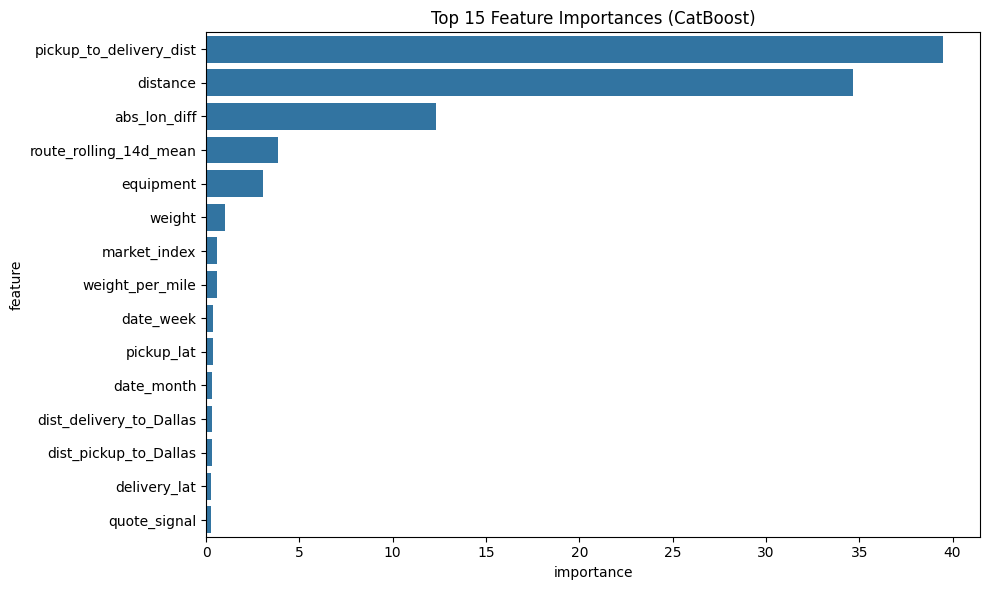

C:\Users\abhis\AppData\Local\Temp\ipykernel_26300\13513519.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, train.loc[val_idx, feature_cols], plot_type='bar')


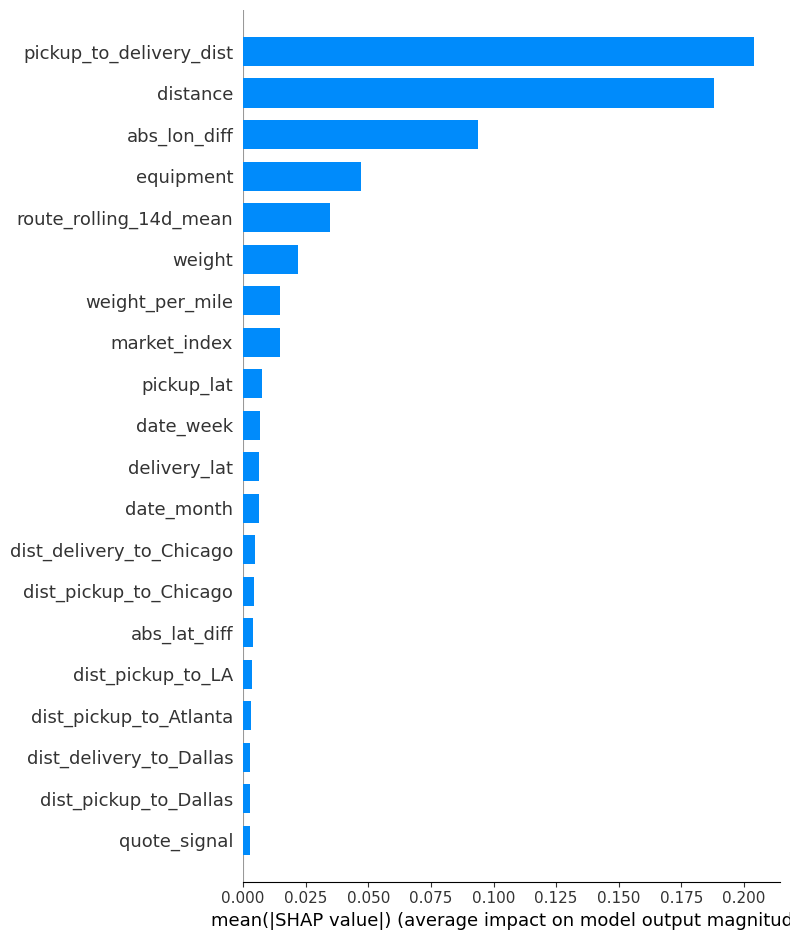

In [14]:
# Attempt 1: Calculating SHAP values directly on the full dataset without background subsampling
# explainer = shap.TreeExplainer(final_model_eval)
# shap_values = explainer.shap_values(train[feature_cols])
# Abandoned: Execution stalled due to large evaluation matrix size.

# Final Approach: Evaluate feature impact on holdout validation fold (Fold 0)
final_model_eval = CatBoostRegressor(**best_params, early_stopping_rounds=50, verbose=0)
train_idx = train[train['fold'] != 0].index
val_idx = train[train['fold'] == 0].index

final_model_eval.fit(
    train.loc[train_idx, feature_cols], train.loc[train_idx, 'log_posted_rate'],
    cat_features=cat_features,
    eval_set=(train.loc[val_idx, feature_cols], train.loc[val_idx, 'log_posted_rate']),
    use_best_model=True
)

val_pred = np.expm1(final_model_eval.predict(train.loc[val_idx, feature_cols]))
print('Fold 0 Holdout Validation RMSE:', rmse(train.loc[val_idx, 'posted_rate'], val_pred))

# Built-in Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols, 
    'importance': final_model_eval.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances (CatBoost)')
plt.tight_layout()
plt.show()

# SHAP Explainer on Fold 0
explainer = shap.TreeExplainer(final_model_eval)
shap_values = explainer.shap_values(train.loc[val_idx, feature_cols])
shap.summary_plot(shap_values, train.loc[val_idx, feature_cols], plot_type='bar')

SATISFIED WITH THE ABOVE EVALUATIONS AND FEATURES

MOVING FORWARD WITH TRAINING ON FULL DATASET AND GENERATING OUTPUT/PREDICTING RATE

In [ ]:
# Attempt 1: Retraining without explicit string casting on categorical features
# final_model_full.fit(train[feature_cols], train['log_posted_rate'], cat_features=cat_features)
# Failed: Threw CatBoost error due to mixed int/string types in zone columns during full fit.

# Final Approach: Ensure explicit string types across all categorical columns before full fit
print("Retraining best model on full dataset...")
best_params['verbose'] = 100 

valid_cat_features = [col for col in cat_features if col in train.columns and col in feature_cols]
for col in valid_cat_features:
    train[col] = train[col].astype(str)
    validation[col] = validation[col].astype(str)
    december_inputs[col] = december_inputs[col].astype(str)

final_model_full = CatBoostRegressor(**best_params)
final_model_full.fit(train[feature_cols], train['log_posted_rate'], cat_features=valid_cat_features)

# Generate predictions and inverse transform from log scale
validation_preds = np.expm1(final_model_full.predict(validation[feature_cols]))
december_preds = np.expm1(final_model_full.predict(december_inputs[feature_cols]))

# Save Validation Deliverable
validation_template = pd.read_csv('D:/offcampus/projects/BN_freight_rate_prediction/data/validation-predictions-template.csv')
validation_template['predicted_rate'] = validation_preds
validation_template.to_csv('D:/offcampus/projects/BN_freight_rate_prediction/validation_predictionsT.csv', index=False)

# Save December Chart Deliverable
december_inputs['predicted_rate'] = december_preds
december_inputs[['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']].to_csv(
    'D:/offcampus/projects/N_freight_rate_prediction/data/december-chart-inputs.csv', index=False
)

# Export Model Binary Artifact
os.makedirs('D:/offcampus/projects/BN_freight_rate_prediction/models', exist_ok=True)
joblib.dump(final_model_full, 'D:/offcampus/projects/BN_freight_rate_prediction/models/BN_freight_rate_model.joblib')

print('Deliverables exported successfully: validation_predictions.csv, december-chart-inputs.csv, and model binary!')

Retraining best model on full dataset...
0:	learn: 0.6454003	total: 93.7ms	remaining: 42.4s
100:	learn: 0.1576099	total: 9.02s	remaining: 31.5s
200:	learn: 0.1526111	total: 18s	remaining: 22.6s


KeyboardInterrupt: 

In [16]:

best_params['verbose'] = 100 

valid_cat_features = [col for col in cat_features if col in train.columns and col in feature_cols]
for col in valid_cat_features:
    train[col] = train[col].astype(str)
    validation[col] = validation[col].astype(str)
    december_inputs[col] = december_inputs[col].astype(str)

final_model_full = CatBoostRegressor(**best_params)
final_model_full.fit(train[feature_cols], train['log_posted_rate'], cat_features=valid_cat_features)

# Generate predictions and inverse transform from log scale
validation_preds = np.expm1(final_model_full.predict(validation[feature_cols]))
december_preds = np.expm1(final_model_full.predict(december_inputs[feature_cols]))

# Save Validation Deliverable
validation_template = pd.read_csv('D:/offcampus/projects/BN_freight_rate_prediction/data/validation-predictions-template.csv')
validation_template['predicted_rate'] = validation_preds
validation_template.to_csv('D:/offcampus/projects/BN_freight_rate_prediction/validation_predictionsT.csv', index=False)

# Save December Chart Deliverable
december_inputs['predicted_rate'] = december_preds
december_inputs[['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']].to_csv(
    'D:/offcampus/projects/N_freight_rate_prediction/data/december-chart-inputs.csv', index=False
)

# Export Model Binary Artifact
os.makedirs('D:/offcampus/projects/BN_freight_rate_prediction/models', exist_ok=True)
joblib.dump(final_model_full, 'D:/offcampus/projects/BN_freight_rate_prediction/models/BN_freight_rate_model.joblib')

print('Deliverables exported successfully: validation_predictions.csv, december-chart-inputs.csv, and model binary!')

0:	learn: 0.6454003	total: 86.2ms	remaining: 39s
100:	learn: 0.1576099	total: 9.2s	remaining: 32.1s
200:	learn: 0.1526111	total: 18s	remaining: 22.6s
300:	learn: 0.1511658	total: 26s	remaining: 13.2s
400:	learn: 0.1502602	total: 34s	remaining: 4.49s
453:	learn: 0.1498102	total: 38.1s	remaining: 0us
Deliverables exported successfully: validation_predictions.csv, december-chart-inputs.csv, and model binary!
